# Практика по Логистической регрессии


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Постановка задачи и генерация данных
Задача: задача - предсказать, закроет ли клиент свой счет в ближайшее время, основываясь на его активности и характеристиках.
Признаки:
1. Возраст клиента
2. Остаток на счете
3. Количество используемых банковских продуктов
4. Проявлял ли клиент активность в последний месяц

Целевая переменная (категориальная): Остался клиент в банке (1) или нет (0).

In [11]:
# Для воспроизводимости
np.random.seed(42)
n_samples = 100

# Генерируем признаки
age = np.random.normal(40, 12, n_samples).clip(18, 80)
balance = np.random.uniform(0, 100000, n_samples)
products = np.random.randint(1, 5, n_samples)
is_active = np.random.binomial(1, 0.6, n_samples)

# Создаем логику для целевой переменной (оттока)
# Клиенты постарше, с низким балансом и низкой активностью уходят чаще
logit = 0.05 * age - 0.00005 * balance - 1.5 * is_active - 2
prob = 1 / (1 + np.exp(-logit))
target = np.random.binomial(1, prob)

# Собираем в DataFrame
df = pd.DataFrame({
    'age': age,
    'balance': balance,
    'products': products,
    'is_active': is_active,
    'exited': target
})

df.head()

,age,balance,products,is_active,exited
0,45.960570,41741.100315,2,0,0
1,38.340828,22210.781047,1,1,0
2,47.772262,11986.536733,2,1,0
3,58.276358,33761.517140,1,1,0
4,37.190160,94290.970391,4,1,0


In [12]:
'Описательные статистики'
df.describe()

,age,balance,products,is_active,exited
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,38.891474,48620.618511,2.480000,0.670000,0.130000
std,10.583505,28814.392415,1.176195,0.472582,0.337998
min,18.000000,506.158385,1.000000,0.000000,0.000000
25%,32.789132,24127.969084,1.000000,0.000000,0.000000
50%,38.476524,50738.604076,2.000000,1.000000,0.000000
75%,44.871425,69467.613799,4.000000,1.000000,0.000000
max,62.227338,98565.045411,4.000000,1.000000,1.000000


## Влияние признаков на целевую переменную

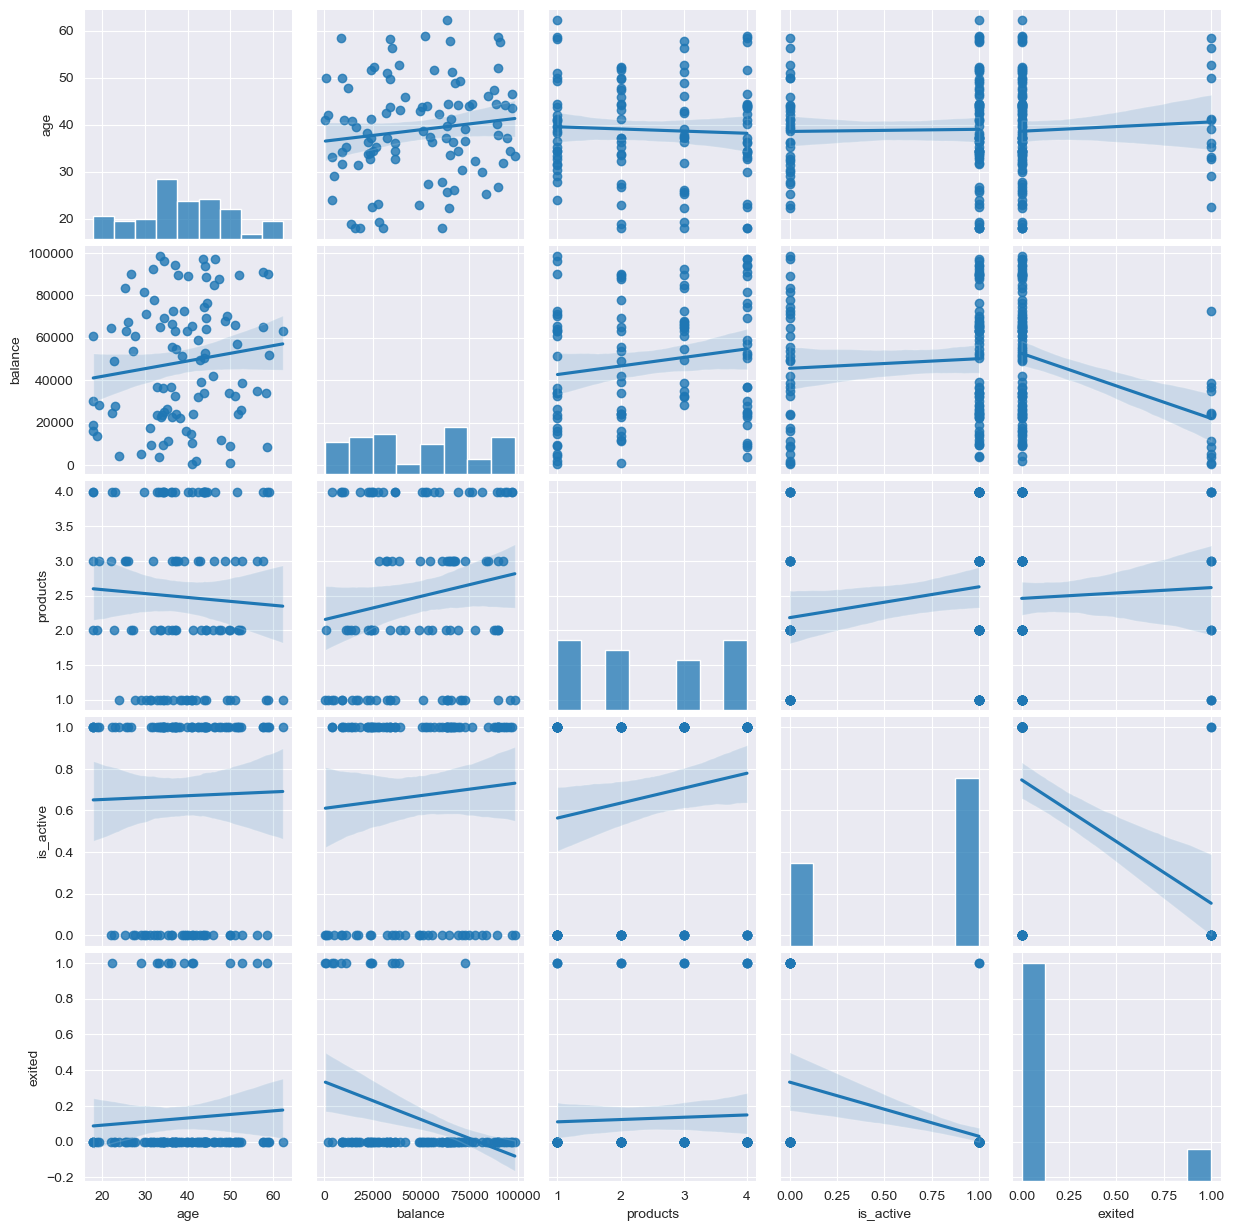

In [13]:
sns.pairplot(df, kind='reg')

## Понятие Логистической регрессии
Логистическая регрессия относится к алгоритмам классификации, так как предсказываем **категориальную** переменную.
Модель будет возвращать вероятность попадания в ту или иную группу от 0 до 1.

Функция стоимости:
$$J(\beta) = -\frac{1} {m} \sum^m_{j=1} y^j\log(\hat{y}^j) + (1-y^j)\log(1-\hat{y}^j)$$
Эта функция основана на принципе Метода Максимального правдоподобия (Maximum Likelihood Estimation), суть которого заключается в максимизации правдоподобия (произведение вероятностей попадания в ту или иную группу: $0.7 * 0.6 * 0.5 * (1 - 0.2) * (1 - 0.4) * (1 - 0.3)$). В функции стоимости используется этот же подход, только считаются не просто вероятности, а натуральные логарифмы по ним (для математического удобства вычисления градиента). Чтобы максимизировать такую формулу, нужно минимизировать отрицательное логарифмическое правдоподобие (Log Loss).

Далее считаем градиент по аналогии с Линейной регрессией. (Частные производные функции стоимости по коэффициентам $\beta$)

Обновляем коэффициенты: $$\beta_j = \beta_j - \alpha * \frac{\partial J} {\partial \beta_j}$$
$\alpha$ - Learning rate или Шаг обучения. Определяет размер шага, который алгоритм при поиске минимума функции потерь. По умолчанию он равен обратному градиенту.

## Построение модели

### Разбиваю данные на обучающую и тестовую выборку

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('exited', axis=1)
y = df['exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Стандартизация
Привожу все переменные в одно измерение

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train

array([[ 1.15235648,  0.63896402,  0.38765744,  0.71374643],
       [-0.4740145 ,  0.60310189, -0.47380354,  0.71374643],
       [-1.16554635,  0.68106358,  0.38765744,  0.71374643],
       [-0.01304186,  0.12658738, -1.33526453, -1.4010578 ],
       [-0.60242808,  1.05433487, -0.47380354, -1.4010578 ],
       [-0.5102226 , -1.51979093,  1.24911843,  0.71374643],
       [ 0.93772424,  0.69987201,  0.38765744,  0.71374643],
       [ 0.44532224,  1.72346197,  1.24911843, -1.4010578 ],
       [ 0.71964902,  1.71920586,  1.24911843,  0.71374643],
       [ 0.07581303, -1.08761606, -1.33526453, -1.4010578 ],
       [-0.40273839, -0.7752739 ,  1.24911843,  0.71374643],
       [ 1.29243882, -0.30772147,  0.38765744, -1.4010578 ],
       [-0.44284251, -0.82562502,  1.24911843,  0.71374643],
       [-0.55291356, -0.82427919, -1.33526453, -1.4010578 ],
       [-0.24904712, -0.37361575,  1.24911843, -1.4010578 ],
       [-0.14493866, -0.52783309,  0.38765744,  0.71374643],
       [ 0.03553437,  0.

### Создание и обучение модели

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(scaled_X_train, y_train)
y_pred = model.predict(scaled_X_test)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Оценка работы модели
#### 1. Базовая оценка (Accuracy)
$$Accuracy = \frac{Правильные\ ответы} {Всего\ примеров}$$

#### 2. Матрица ошибок (Confusion Matrix)
Возвращает матрицу 2x2:
- TN - True Negative (Правильное предсказание, что тест НЕ пройден)
- FN - False Negative (Ошибочное предсказание, что тест НЕ пройден)
- FP - False Positive (Ошибочное предсказание, что тест пройден)
- TP - True Positive (Правильное предсказание, что тест пройден)

#### 3. Детальный отчёт (precision, recall, f1-score)
1. Precision - Из всех, кого назвали "пройдёт" - сколько действительно прошли. $$Precision = \frac{TP} {(TP + FP)}$$
2. Recall - Из всех, кто реально прошёл — сколько мы нашли. $$Recall = \frac{TP} {(TP + FN)}$$
3. F1-Score - Баланс между Precision и Recall. $$F1 = Гармоническое\ среднее$$

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

'Базовая точность'
accuracy = accuracy_score(y_test, y_pred)
print(f'Базовая точность модели = {accuracy}')

Базовая точность модели = 1.0


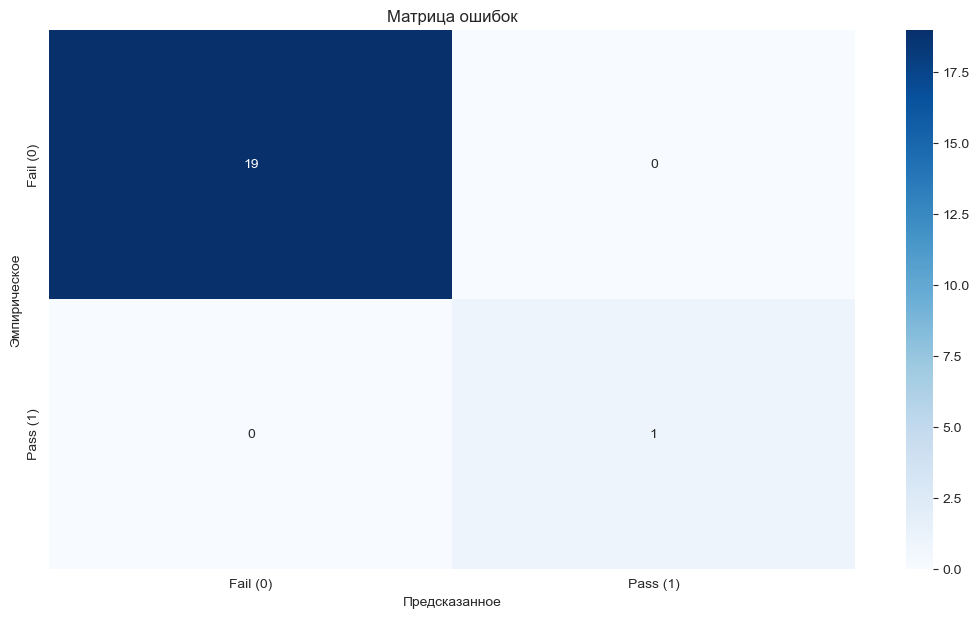

In [34]:
'Матрица ошибок'
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(13, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail (0)', 'Pass (1)'],
            yticklabels=['Fail (0)', 'Pass (1)'])
plt.xlabel('Предсказанное')
plt.title('Матрица ошибок')
plt.ylabel('Эмпирическое');

In [39]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         1

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



Наша модель показала очень хорошие результаты! Из 20 тестовых данных она дала 20 правильных предсказаний!

### Предсказание на примере клиента с такими признаками:
1. Возраст = 52 года
2. Баланс = 15400
3. Количество продуктов = 1
4. Активность за последний месяц = 0 (неактивен)


In [43]:
new_client = pd.DataFrame([[52, 15400.0, 1, 0]], columns=['age', 'balance', 'products', 'is_active'])

new_client_scaled = scaler.transform(new_client)
pred = model.predict(new_client_scaled)

print(f'Предсказание = {pred[0]}')

Предсказание = 0


Таким образом, модель предсказала, что такой клиент НЕ останется в банке.